# SHAP Explainable AI Analysis

In [1]:
import pandas as pd
import shap
import joblib

c:\Users\Farhan Ruhullah\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
model = joblib.load("../models/rice_yield_model_time_validated.pkl")
df = pd.read_csv("../data/climate_food_security_FINAL.csv")

df.head()

,country,iso_code,income_group,year,rice_yield,temperature,rainfall,fertilizer,gdp_per_capita,disaster_events,flood_events,drought_events,temperature_change,rainfall_change_percent,disaster_risk_score,climate_risk_level
0,Afghanistan,AFG,Low income,2001,2.0000,10.47,327,2.394898,277.118051,5.0,0.0,0.0,0.0,0.0,5.0,Medium
1,Algeria,DZA,Upper middle income,2001,1.2371,18.99,89,13.886325,3610.006056,1.0,1.0,0.0,0.0,0.0,2.5,Medium
2,Azerbaijan,AZE,Upper middle income,2001,4.8495,12.09,447,6.482541,1640.936645,0.0,0.0,0.0,0.0,0.0,0.0,Low
3,Bangladesh,BGD,Lower middle income,2001,3.4470,25.20,2666,174.590269,641.288923,7.0,2.0,0.0,0.0,0.0,10.0,High
4,Belize,BLZ,Upper middle income,2001,3.0137,25.11,1705,72.307692,5764.990555,2.0,0.0,0.0,0.0,0.0,2.0,Low


In [7]:
features = [
    "temperature",
    "rainfall",
    "fertilizer",
    "gdp_per_capita",
    "disaster_events",
    "flood_events",
    "drought_events",
    "temperature_change",
    "rainfall_change_percent"
]

In [8]:
test = df[df["year"] >= 2020]

X_test = test[features].fillna(0)

y_test = test["rice_yield"]

In [9]:
explainer = shap.TreeExplainer(model)

# Generate SHAP values for test data
shap_values = explainer.shap_values(X_test)

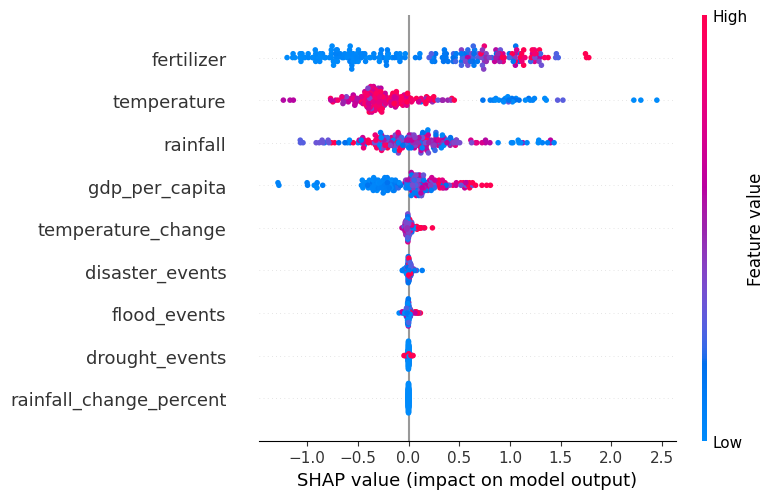

In [10]:
shap.summary_plot(shap_values, X_test)